In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier,AdaBoostClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,ConfusionMatrixDisplay,classification_report,auc,RocCurveDisplay
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Heart_Disease.csv")

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [4]:
df_corr = df.corr()

<Axes: >

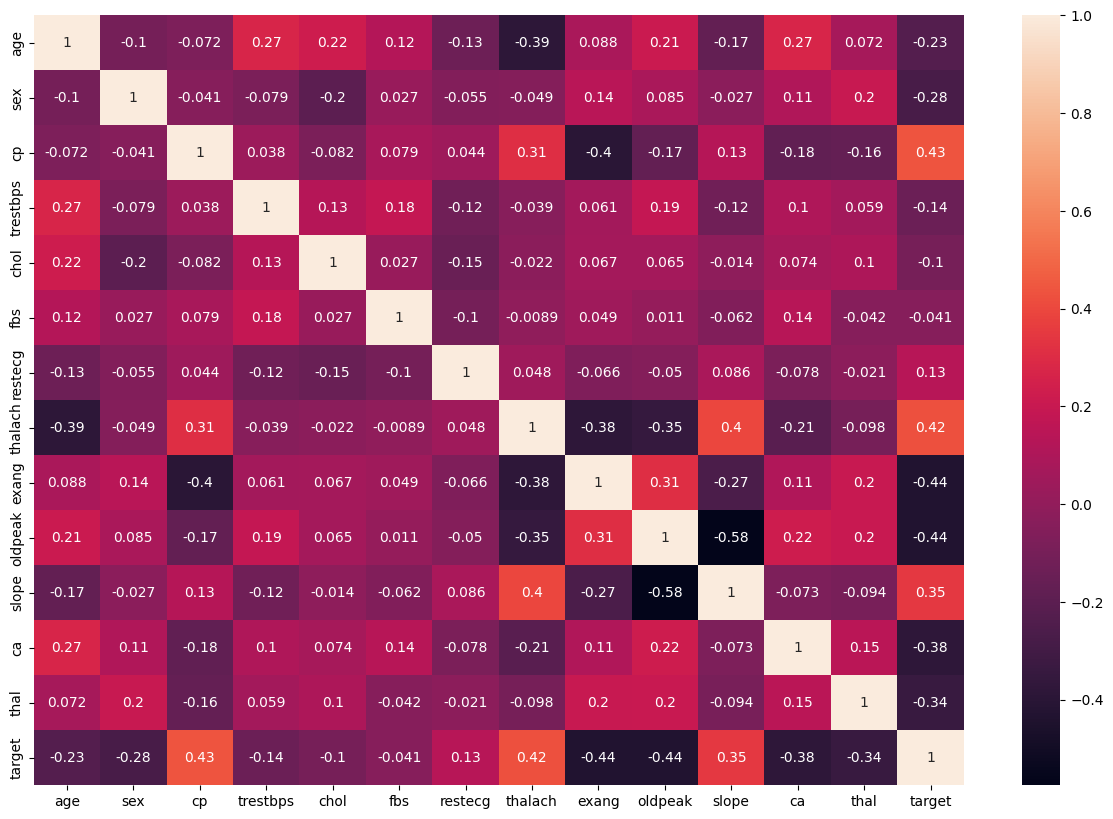

In [5]:
plt.figure(figsize=(15,10))
sns.heatmap(df_corr,annot=True)

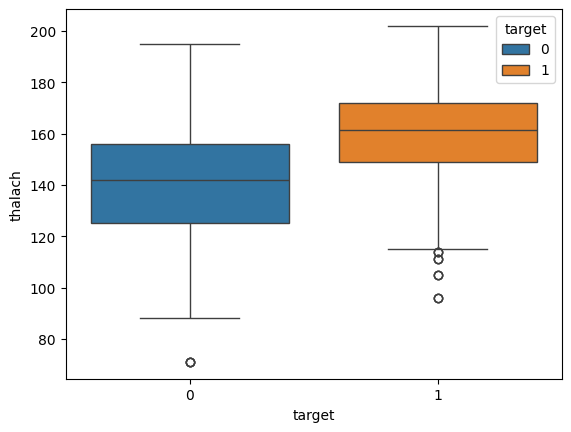

In [35]:
sns.boxplot(y=df['thalach'],x=df['target'],hue=df['target'])
plt.show()

In [7]:
model1 = RandomForestClassifier(n_estimators=100,criterion='entropy')
model2 = AdaBoostClassifier(n_estimators=100,learning_rate=0.1,random_state=42)

In [8]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [9]:
df.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
age,1025.0,54.434146,9.072290,29.0,48.0,56.0,61.0,77.0
sex,1025.0,0.695610,0.460373,0.0,0.0,1.0,1.0,1.0
cp,1025.0,0.942439,1.029641,0.0,0.0,1.0,2.0,3.0
trestbps,1025.0,131.611707,17.516718,94.0,120.0,130.0,140.0,200.0
chol,1025.0,246.000000,51.592510,126.0,211.0,240.0,275.0,564.0
fbs,1025.0,0.149268,0.356527,0.0,0.0,0.0,0.0,1.0
restecg,1025.0,0.529756,0.527878,0.0,0.0,1.0,1.0,2.0
thalach,1025.0,149.114146,23.005724,71.0,132.0,152.0,166.0,202.0
exang,1025.0,0.336585,0.472772,0.0,0.0,0.0,1.0,1.0
oldpeak,1025.0,1.071512,1.175053,0.0,0.0,0.8,1.8,6.2


In [10]:
x = df.drop(columns=['target'])
y = df['target']

In [11]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [12]:
model1.fit(x_train,y_train)


,n_estimators,100
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [13]:
model2.fit(x_train,y_train)

,estimator,None
,n_estimators,100
,learning_rate,0.1
,algorithm,'deprecated'
,random_state,42


In [14]:
y_pred1 = model1.predict(x_test)
y_pred2 = model2.predict(x_test)

In [ ]:
acc1 = accuracy_score(y_test,y_pred1)
acc2 = accuracy_score(y_test,y_pred2)

cm1 = confusion_matrix(y_test,y_pred1,)
cm2 = confusion_matrix(y_test,y_pred2)

cr1 = classification_report(y_test,y_pred1,output_dict=True)
cr2 = classification_report(y_test,y_pred2,output_dict=True)

#important

In [16]:
print(acc1)
print(acc2)
print(cm1)
print(cm2)
print(cr1)
print(cr2)

0.9853658536585366
0.7853658536585366
[[102   0]
 [  3 100]]
[[71 31]
 [13 90]]
              precision    recall  f1-score   support

           0       0.97      1.00      0.99       102
           1       1.00      0.97      0.99       103

    accuracy                           0.99       205
   macro avg       0.99      0.99      0.99       205
weighted avg       0.99      0.99      0.99       205

              precision    recall  f1-score   support

           0       0.85      0.70      0.76       102
           1       0.74      0.87      0.80       103

    accuracy                           0.79       205
   macro avg       0.79      0.78      0.78       205
weighted avg       0.79      0.79      0.78       205



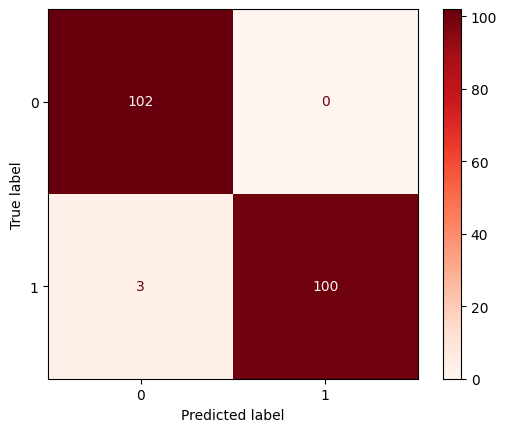

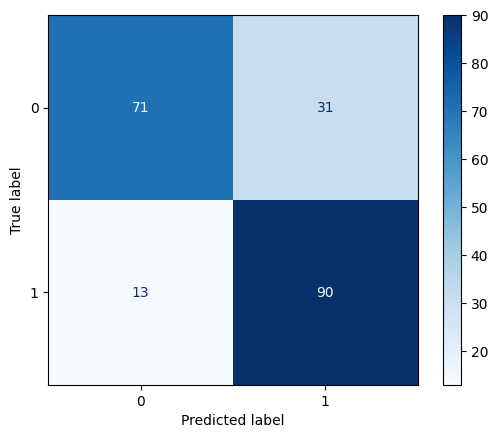

In [17]:
cmd1 = ConfusionMatrixDisplay(confusion_matrix=cm1,display_labels=model1.classes_)
cmd1.plot(cmap='Reds')

cmd2 = ConfusionMatrixDisplay(confusion_matrix=cm2,display_labels=model2.classes_)
cmd2.plot(cmap='Blues')

In [18]:
from sklearn.metrics import RocCurveDisplay

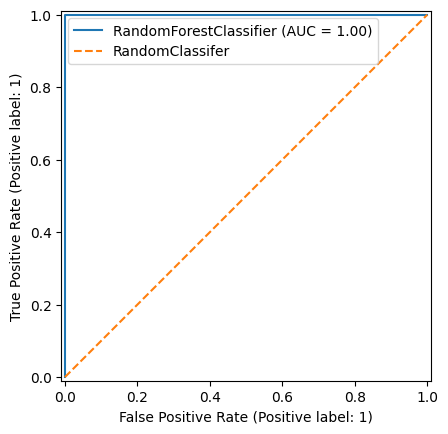

In [19]:
RocCurveDisplay.from_estimator(model1,x_test,y_test)
plt.plot([0,1],[0,1],'--',label='RandomClassifer')
# plt.plot([0,1],[0,1],'--',label='Random Classifier')
plt.legend()
plt.show()

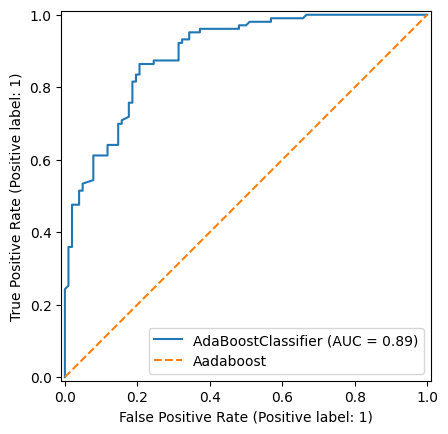

In [20]:
RocCurveDisplay.from_estimator(model2,x_test,y_test)
plt.plot([0,1],[0,1],'--',label='Aadaboost')
plt.legend()
plt.show()

In [27]:
pacc = cr2['accuracy']
pper = cr2['weighted avg']['precision']
prec =  cr2['weighted avg']['recall']
pf1 =  cr2['weighted avg']['f1-score']
      

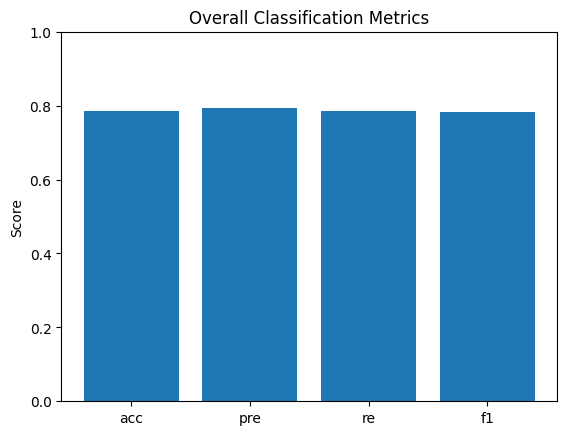

In [29]:
metrics = ['acc','pre','re','f1']
values = [pacc,pper,prec,pf1]

plt.bar(metrics,values)
plt.ylim(0, 1)
plt.title('Overall Classification Metrics')
plt.ylabel('Score')
plt.show()

In [36]:
fi = model1.feature_importances_
f = x.columns

In [39]:
fida = pd.DataFrame({"feat":f,"imp":fi}).sort_values("imp",ascending=False)

In [40]:
fida.head()

,feat,imp
11,ca,0.130688
2,cp,0.127261
7,thalach,0.122100
9,oldpeak,0.112631
12,thal,0.105971


<Axes: xlabel='imp', ylabel='feat'>

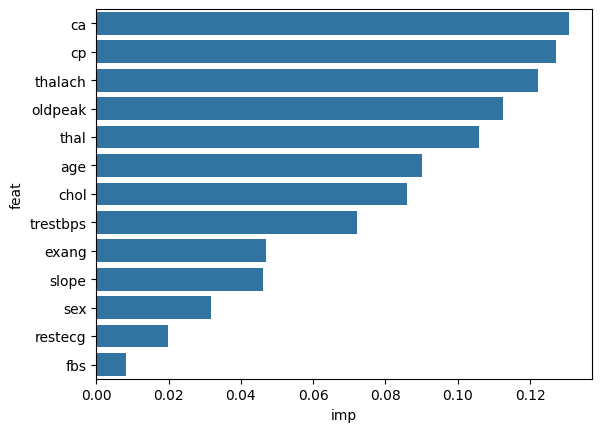

In [45]:
sns.barplot(x=fida['imp'],y=fida['feat'],data=fida)